In [1]:
import CalculatedFieldSubroutines as cfs

#

import numpy as np

import pandas as pd

import random

#

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import KFold

from sklearn.metrics import confusion_matrix

#

from bayes_opt import BayesianOptimization

#

import matplotlib.pyplot as plt

import cartopy.crs as ccrs

from cartopy.io.img_tiles import GoogleTiles

from pandasgui import show

#

import warnings

In [2]:
gmID_list = cfs.list_whitelisted_gmIDs_with_traffic_data()

topic_list = cfs.list_topics()

print( topic_list )

['/apollo/canbus/chassis', '/apollo/drive/event', '/apollo/sensor/gnss/best/pose', '/apollo/perception/traffic/light']


In [3]:
moving_window = 10 # seconds

expansion_window = 1e9 # nanoseconds

#

red_preprocessed_dfs = []

green_preprocessed_dfs = []

blue_preprocessed_dfs = []

for gmID in gmID_list:

    preprocessed_df = cfs.retrieve_gmID_preprocessed_moving_data( gmID, window_seconds = moving_window )

    #

    cfs.BinaryDisengagementExpanded( preprocessed_df, moving_colname = 'time', window = expansion_window )

    #

    cfs.DisengagementID( preprocessed_df, expanded = False )

    cfs.DisengagementID( preprocessed_df, expanded = True )

    #

    if ( cfs.give_route( gmID ) == 'Red' ):

        red_preprocessed_dfs.append( preprocessed_df )

    elif ( cfs.give_route( gmID ) == 'Green' ):

        green_preprocessed_dfs.append( preprocessed_df )

    elif ( cfs.give_route( gmID ) == 'Blue' ):

        blue_preprocessed_dfs.append( preprocessed_df )

In [4]:
red_train_gmIDs = [ 
'61b12e7a-f234-11ee-bb33-fb353e7798cd',
'fcc6fcd2-f013-11ee-b966-fb353e7798cd',
'05c7c824-cab8-11ee-aa4d-1d66adf2f0c7',
'211bdb36-f0da-11ee-ba1b-fb353e7798cd',
'868de15e-f3b3-11ee-bb4e-fb353e7798cd',
'72a03d4a-efe9-11ee-b966-fb353e7798cd',
'7fb7b9c0-c881-11ee-a7fc-dd032dba19e8',
'96f7a614-f549-11ee-8afa-cb629b0d53e6',
'1bbbfbae-c839-11ee-a7fc-dd032dba19e8',
'622bd2e8-f0e4-11ee-ba1f-fb353e7798cd',
'9798fe24-f143-11ee-ba78-fb353e7798cd',
'88dd6fbe-f224-11ee-bb21-fb353e7798cd',
'c9c6856c-d33c-11ee-b437-336917683bb8',
'd12cd1c4-caec-11ee-909c-e1dc60cf66f9',
'817d6848-efb6-11ee-b966-fb353e7798cd',
'1b6aca0e-efdf-11ee-b966-fb353e7798cd',
'41b67a28-f52f-11ee-8afa-cb629b0d53e6',
'fc211bb2-efca-11ee-b966-fb353e7798cd',
'84d96f18-f214-11ee-bb13-fb353e7798cd',
'fe973c9c-f53c-11ee-8afa-cb629b0d53e6',
'3151e9e2-eff3-11ee-b966-fb353e7798cd',
'c0555ef0-f50f-11ee-8afa-cb629b0d53e6',
'f711e68e-f0e1-11ee-ba1f-fb353e7798cd',
'c338788a-d324-11ee-b437-336917683bb8',
'd21965e6-f0fa-11ee-ba37-fb353e7798cd',
'88a68dd8-eef9-11ee-9385-ef789ffde1d3',
'f41cbd44-eff8-11ee-b966-fb353e7798cd',
'43a1a35e-f362-11ee-bb4e-fb353e7798cd',
'6d2ea45a-c839-11ee-a7fc-dd032dba19e8',
'01e65360-efd4-11ee-b966-fb353e7798cd',
'7cbd932e-f244-11ee-bb3f-fb353e7798cd',
'65cfbfd6-f396-11ee-bb4e-fb353e7798cd',
'94c53148-eeed-11ee-9385-ef789ffde1d3',
'fd1ab258-efa7-11ee-b966-fb353e7798cd',
'e7b934a8-ef1a-11ee-9385-ef789ffde1d3',
'de933de8-f112-11ee-ba4d-fb353e7798cd',
'd3698592-ef9d-11ee-b966-fb353e7798cd',
'dd72fdec-f0cf-11ee-ba0d-fb353e7798cd',
'b82476fe-f1f3-11ee-baff-fb353e7798cd',
'f755cf60-f132-11ee-ba6d-fb353e7798cd',
'853ef120-cad3-11ee-909c-e1dc60cf66f9',
'f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd',
'cf831f42-f353-11ee-bb4e-fb353e7798cd',
'ecebb942-f162-11ee-ba97-fb353e7798cd',
'219f7eb8-ef87-11ee-b966-fb353e7798cd',
'd24820c8-f197-11ee-babe-fb353e7798cd',
'3d2d29ec-ef95-11ee-b966-fb353e7798cd',
'457dc5ee-f02a-11ee-b966-fb353e7798cd',
'2462c9d0-eecd-11ee-9385-ef789ffde1d3',
'51ef6da6-ca9f-11ee-909c-e1dc60cf66f9',
'c25271be-f3a4-11ee-bb4e-fb353e7798cd',
'8347b862-efad-11ee-b966-fb353e7798cd',
'8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd',
'9189a2a8-f121-11ee-ba5b-fb353e7798cd',
'8fa6fe80-c869-11ee-a7fc-dd032dba19e8' 
]

red_training_dfs, red_testing_dfs = [], []

for df in red_preprocessed_dfs:

    if df[ 'groupMetadataID' ][ 0 ] in red_train_gmIDs:

        red_training_dfs.append( df )

    else:

        red_testing_dfs.append( df )

In [5]:
X_colnames = [ 'speedMps_mean', 'brakePercentage_mean', 'throttlePercentage_mean', 'steeringPercentage_mean', 'LatLonTotalStdDev_mean',
               'speedMps_stddev', 'brakePercentage_stddev', 'throttlePercentage_stddev', 'steeringPercentage_stddev', 'LatLonTotalStdDev_stddev' ]

y_colname = 'BinaryDisengagementExpanded'

In [6]:
def function_to_maximize( min_samples_split, min_samples_leaf ):

    value = cfs.BinaryClassification_DecisionTree_CV( train_dfs = red_training_dfs, \
                                                      X_colnames = X_colnames, \
                                                      y_colname = y_colname, \
                                                      metric_function = cfs.mf_fbeta_score, \
                                                      dt_random_state = 0, \
                                                      cv_num_of_splits = 5, \
                                                      cv_shuffle = False, \
                                                      cv_random_state = None, \
                                                      y_labels = [ 0, 1 ], \
                                                      criterion = 'entropy', \
                                                      min_samples_split = round( min_samples_split ),
                                                      min_samples_leaf = round( min_samples_leaf ) )

    return value

In [7]:
parameters = {

    'min_samples_split': 93,

    'min_samples_leaf': 102
}

In [8]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = red_training_dfs, \
                                                                               test_dfs = red_training_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [9]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 2533, False_Positives: 1597
False_Negatives: 13174, True_Negatives: 2880072

Positive_Precision: 0.613

Positive_Recall: 0.161

F1_Score: 0.255

Accuracy: 0.995
Balanced_Accuracy: 0.578


In [10]:
red_training_df = pd.concat( red_training_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = red_training_df[ 'DisengagementExpandedID' ] )

#

del red_training_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.196
num_of_unique_tp_DisengagementIDs: 91
num_of_unique_DisengagementIDs: 464


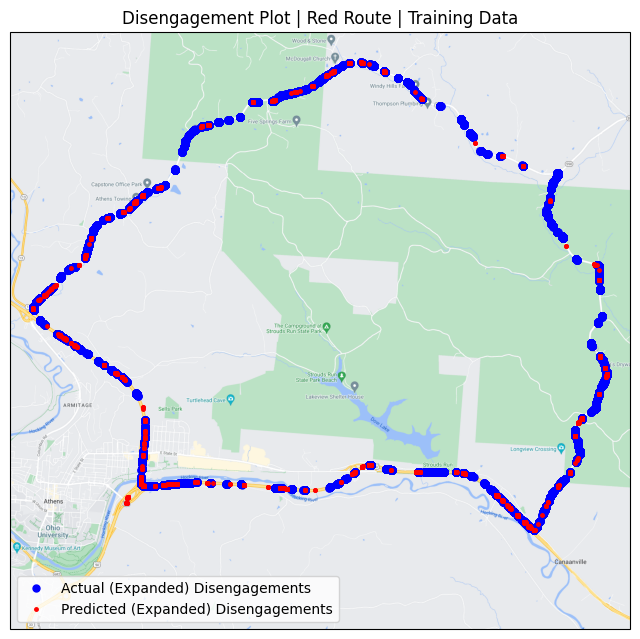

In [11]:
plt.figure( figsize = ( 8, 8 ) )

#

red_preprocessed_df = pd.concat( red_preprocessed_dfs )

#

minLat = np.min( np.array( red_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( red_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( red_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( red_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del red_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

red_training_df = pd.concat( red_training_dfs )

red_training_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  red_training_df[ red_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  red_training_df[ red_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  red_training_df[ red_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  red_training_df[ red_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del red_training_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Red Route | Training Data' )

plt.legend()

plt.show()

In [13]:
print( f'minLat: { minLat }' )

print( f'maxLat: { maxLat }' )

print( f'minLon: { minLon }' )

print( f'maxLon: { maxLon }' )

minLat: 39.3124906671225
maxLat: 39.40448581121833
minLon: -82.10582075491102
maxLon: -81.9788697421841


In [14]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = red_training_dfs, \
                                                                               test_dfs = red_testing_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [15]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 155, False_Positives: 3706
False_Negatives: 4858, True_Negatives: 781462

Positive_Precision: 0.040

Positive_Recall: 0.031

F1_Score: 0.035

Accuracy: 0.989
Balanced_Accuracy: 0.512


In [16]:
red_testing_df = pd.concat( red_testing_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = red_testing_df[ 'DisengagementExpandedID' ] )

#

del red_testing_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.038
num_of_unique_tp_DisengagementIDs: 6
num_of_unique_DisengagementIDs: 158


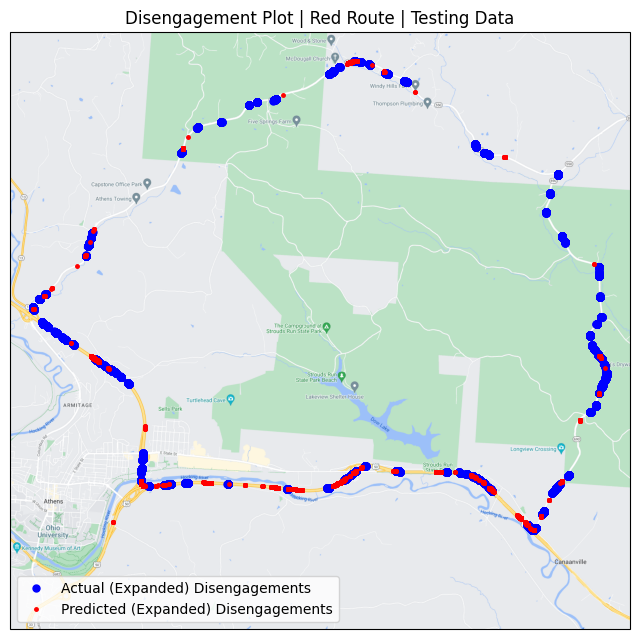

In [17]:
plt.figure( figsize = ( 8, 8 ) )

#

red_preprocessed_df = pd.concat( red_preprocessed_dfs )

#

minLat = np.min( np.array( red_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( red_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( red_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( red_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del red_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

red_testing_df = pd.concat( red_testing_dfs )

red_testing_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  red_testing_df[ red_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  red_testing_df[ red_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  red_testing_df[ red_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  red_testing_df[ red_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del red_testing_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Red Route | Testing Data' )

plt.legend()

plt.show()

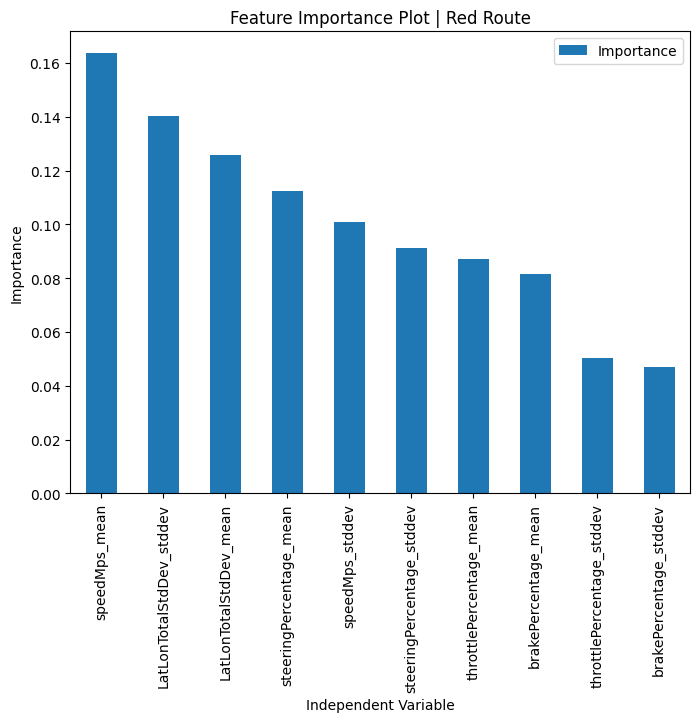

In [18]:
feat_importances = pd.DataFrame( model.feature_importances_, index = X_colnames, columns = [ "Importance" ] )

feat_importances.sort_values( by = 'Importance', ascending = False, inplace = True )

feat_importances.plot( kind = 'bar', figsize = ( 8, 6 ) )

plt.xlabel( 'Independent Variable' )

plt.ylabel( 'Importance' )

plt.title( 'Feature Importance Plot | Red Route' )

plt.show()

In [19]:
#

In [20]:
green_train_gmIDs = [ 
'3ec95686-f053-11ee-b988-fb353e7798cd',
'b31aca98-cb95-11ee-909c-e1dc60cf66f9',
'25e27b86-f06a-11ee-b9a3-fb353e7798cd',
'bf9157f0-f16b-11ee-ba9e-fb353e7798cd',
'51b74168-f19d-11ee-babf-fb353e7798cd',
'de493be2-f10f-11ee-ba4b-fb353e7798cd',
'ece2a8be-f047-11ee-b97d-fb353e7798cd',
'044d976e-f0e5-11ee-ba20-fb353e7798cd',
'98692fde-f1a4-11ee-bac6-fb353e7798cd',
'5afabc8c-f035-11ee-b966-fb353e7798cd',
'072ef896-cbac-11ee-909c-e1dc60cf66f9',
'c59a54e0-f179-11ee-baab-fb353e7798cd',
'bbbd0cc6-f0dc-11ee-ba1e-fb353e7798cd',
'ba87f3ec-f07e-11ee-b9b4-fb353e7798cd',
'96ceec56-f1cf-11ee-bae4-fb353e7798cd',
'40706f50-f03b-11ee-b96e-fb353e7798cd',
'f570c51c-f15d-11ee-ba91-fb353e7798cd',
'f12112ba-f1c0-11ee-bada-fb353e7798cd',
'961fd9cc-f103-11ee-ba3f-fb353e7798cd',
'5f7ce340-f1c8-11ee-bae0-fb353e7798cd',
'cf7148d8-f058-11ee-b98a-fb353e7798cd',
'848e44a6-f134-11ee-ba6d-fb353e7798cd',
'3a7dc9a6-f042-11ee-b974-fb353e7798cd',
'c9be2042-f0de-11ee-ba1e-fb353e7798cd',
'9736e77c-f187-11ee-bab6-fb353e7798cd',
'5fc763f6-f1ab-11ee-bacd-fb353e7798cd',
'4c88757c-f157-11ee-ba89-fb353e7798cd',
'a231c0b0-f142-11ee-ba76-fb353e7798cd',
'53fad09e-f0f7-11ee-ba2f-fb353e7798cd',
'5c7a9ab2-f13b-11ee-ba72-fb353e7798cd',
'4cf81634-f238-11ee-bb34-fb353e7798cd',
'a08a8c7e-f1fb-11ee-bb05-fb353e7798cd',
'3ed4aa16-f1d6-11ee-bae6-fb353e7798cd',
'25135418-f250-11ee-bb4a-fb353e7798cd',
'c1b320e2-f079-11ee-b9b0-fb353e7798cd',
'43abeb00-f206-11ee-bb07-fb353e7798cd',
'fe0395f0-f1ea-11ee-baf9-fb353e7798cd',
'3d8020aa-cb7f-11ee-909c-e1dc60cf66f9',
'14b6bc9c-f064-11ee-b998-fb353e7798cd',
'870cfd32-f1b9-11ee-bad5-fb353e7798cd',
'c2f54552-f06f-11ee-b9a9-fb353e7798cd',
'dea29156-f123-11ee-ba5d-fb353e7798cd',
'3c415ade-d353-11ee-b437-336917683bb8',
'a901fe40-f0fd-11ee-ba39-fb353e7798cd',
'c4146d46-f074-11ee-b9ac-fb353e7798cd',
'de226278-f25a-11ee-bb4e-fb353e7798cd',
'd7cb9c92-f164-11ee-ba97-fb353e7798cd',
'88b0613a-d35d-11ee-b437-336917683bb8',
'c4fca7bc-f18e-11ee-bab8-fb353e7798cd',
'ed352100-cba0-11ee-909c-e1dc60cf66f9',
'cbdc93f4-f255-11ee-bb4e-fb353e7798cd',
'8e5c4fc2-f149-11ee-ba7f-fb353e7798cd',
'bb4d37d4-f109-11ee-ba46-fb353e7798cd',
'236836f6-f1dd-11ee-bae8-fb353e7798cd',
'7948628e-f20b-11ee-bb0f-fb353e7798cd',
'c14299be-f180-11ee-bab0-fb353e7798cd',
'73bc30cc-f150-11ee-ba84-fb353e7798cd',
'7e3d64da-f12d-11ee-ba68-fb353e7798cd',
'837fc882-cb5a-11ee-909c-e1dc60cf66f9',
'f8fd0fd8-f243-11ee-bb3f-fb353e7798cd',
'58d78342-f24a-11ee-bb45-fb353e7798cd',
'8adb6498-f04d-11ee-b981-fb353e7798cd',
'271fee10-cb8b-11ee-909c-e1dc60cf66f9',
'99b9f446-f1b2-11ee-bad3-fb353e7798cd'
]

green_training_dfs, green_testing_dfs = [], []

for df in green_preprocessed_dfs:

    if df[ 'groupMetadataID' ][ 0 ] in green_train_gmIDs:

        green_training_dfs.append( df )

    else:

        green_testing_dfs.append( df )

In [21]:
def function_to_maximize( min_samples_split, min_samples_leaf ):

    value = cfs.BinaryClassification_DecisionTree_CV( train_dfs = green_training_dfs, \
                                                      X_colnames = X_colnames, \
                                                      y_colname = y_colname, \
                                                      metric_function = cfs.mf_fbeta_score, \
                                                      dt_random_state = 0, \
                                                      cv_num_of_splits = 5, \
                                                      cv_shuffle = False, \
                                                      cv_random_state = None, \
                                                      y_labels = [ 0, 1 ], \
                                                      criterion = 'entropy', \
                                                      min_samples_split = round( min_samples_split ),
                                                      min_samples_leaf = round( min_samples_leaf ) )

    return value

In [22]:
parameters = {

    'min_samples_split': 118,

    'min_samples_leaf': 164
}

In [23]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = green_training_dfs, \
                                                                               test_dfs = green_training_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [24]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 1552, False_Positives: 987
False_Negatives: 7532, True_Negatives: 1712753

Positive_Precision: 0.611

Positive_Recall: 0.171

F1_Score: 0.267

Accuracy: 0.995
Balanced_Accuracy: 0.583


In [25]:
green_training_df = pd.concat( green_training_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = green_training_df[ 'DisengagementExpandedID' ] )

#

del green_training_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.234
num_of_unique_tp_DisengagementIDs: 66
num_of_unique_DisengagementIDs: 282


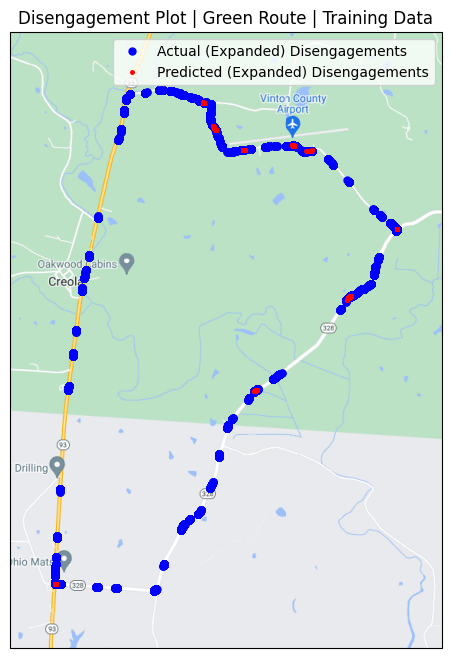

In [26]:
plt.figure( figsize = ( 8, 8 ) )

#

green_preprocessed_df = pd.concat( green_preprocessed_dfs )

#

minLat = np.min( np.array( green_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( green_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( green_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( green_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del green_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

green_training_df = pd.concat( green_training_dfs )

green_training_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  green_training_df[ green_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  green_training_df[ green_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  green_training_df[ green_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  green_training_df[ green_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del green_training_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Green Route | Training Data' )

plt.legend()

plt.show()

In [28]:
print( f'minLat: { minLat }' )

print( f'maxLat: { maxLat }' )

print( f'minLon: { minLon }' )

print( f'maxLon: { maxLon }' )

minLat: 39.28843222457655
maxLat: 39.33215131664078
minLon: -82.46754600607878
maxLon: -82.4289058208249


In [29]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = green_training_dfs, \
                                                                               test_dfs = green_testing_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [30]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 185, False_Positives: 1130
False_Negatives: 2977, True_Negatives: 450277

Positive_Precision: 0.141

Positive_Recall: 0.059

F1_Score: 0.083

Accuracy: 0.991
Balanced_Accuracy: 0.526


In [31]:
green_testing_df = pd.concat( green_testing_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = green_testing_df[ 'DisengagementExpandedID' ] )

#

del green_testing_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.099
num_of_unique_tp_DisengagementIDs: 9
num_of_unique_DisengagementIDs: 91


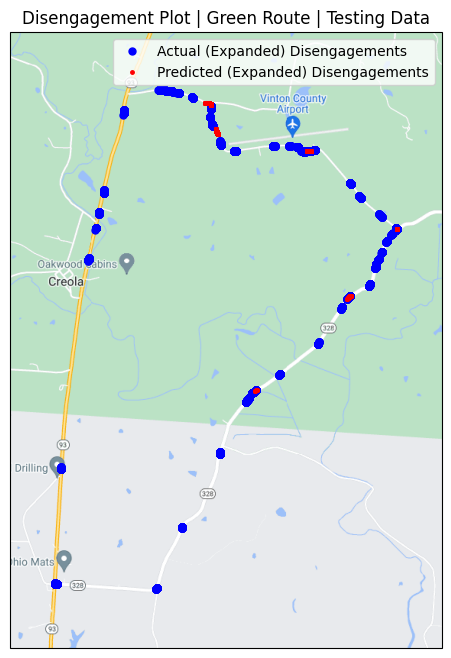

In [32]:
plt.figure( figsize = ( 8, 8 ) )

#

green_preprocessed_df = pd.concat( green_preprocessed_dfs )

#

minLat = np.min( np.array( green_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( green_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( green_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( green_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del green_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

green_testing_df = pd.concat( green_testing_dfs )

green_testing_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  green_testing_df[ green_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  green_testing_df[ green_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  green_testing_df[ green_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  green_testing_df[ green_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del green_testing_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Green Route | Testing Data' )

plt.legend()

plt.show()

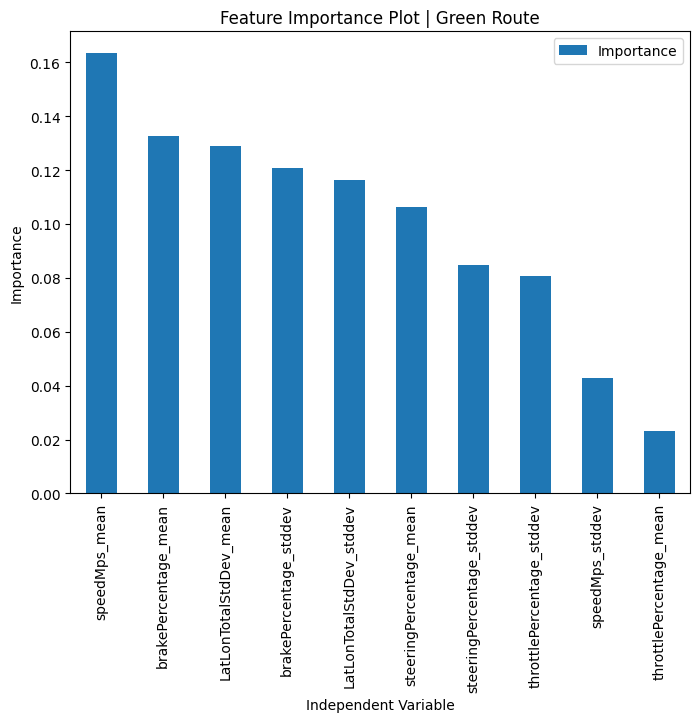

In [33]:
feat_importances = pd.DataFrame( model.feature_importances_, index = X_colnames, columns = [ "Importance" ] )

feat_importances.sort_values( by = 'Importance', ascending = False, inplace = True )

feat_importances.plot( kind = 'bar', figsize = ( 8, 6 ) )

plt.xlabel( 'Independent Variable' )

plt.ylabel( 'Importance' )

plt.title( 'Feature Importance Plot | Green Route' )

plt.show()

In [34]:
#

In [35]:
blue_train_gmIDs = [ 
'7228e03a-ebf0-11ee-b297-3b0ad9d5d6c6',
'8c57e8ac-dbec-11ee-a158-97f8443fd730',
'17876fec-ea66-11ee-b297-3b0ad9d5d6c6',
'd1d090d4-ea7c-11ee-b297-3b0ad9d5d6c6',
'ed7f2038-ea1e-11ee-b297-3b0ad9d5d6c6',
'6af236d6-d98f-11ee-a158-97f8443fd730',
'64737d98-d312-11ee-b437-336917683bb8',
'5240e750-ec30-11ee-b297-3b0ad9d5d6c6',
'7613801a-edcb-11ee-9385-ef789ffde1d3',
'68c289fa-dbd4-11ee-a158-97f8443fd730',
'76683d3c-db18-11ee-a158-97f8443fd730',
'69ab88ec-dc17-11ee-a158-97f8443fd730',
'7f09f6c6-a5b0-11ee-88ec-eb6a8d5269b4',
'3d2a80f0-ec81-11ee-b297-3b0ad9d5d6c6',
'feaf2ba8-d28d-11ee-b437-336917683bb8',
'e2079a78-dc1d-11ee-a158-97f8443fd730',
'b224ef9c-ec10-11ee-b297-3b0ad9d5d6c6',
'ba28b352-ec8f-11ee-b297-3b0ad9d5d6c6',
'59c189d8-ed54-11ee-9385-ef789ffde1d3',
'2d35c522-eba2-11ee-b297-3b0ad9d5d6c6',
'3343fd3c-eb87-11ee-b297-3b0ad9d5d6c6',
'c0624e24-d9aa-11ee-a158-97f8443fd730',
'a253145a-d2a6-11ee-b437-336917683bb8',
'9830d896-d2dc-11ee-b437-336917683bb8',
'aa86a660-dc05-11ee-a158-97f8443fd730',
'90101c36-a621-11ee-88ec-eb6a8d5269b4',
'82d39c74-ea59-11ee-b297-3b0ad9d5d6c6',
'f9d62032-db2a-11ee-a158-97f8443fd730',
'af10e22a-ebb1-11ee-b297-3b0ad9d5d6c6',
'47561998-d9c3-11ee-a158-97f8443fd730',
'64875cc0-d054-11ee-9435-f7e542e2436c',
'df8e3742-ec54-11ee-b297-3b0ad9d5d6c6',
'3a2a78cc-db21-11ee-a158-97f8443fd730',
'21a9830-ece6-11ee-b297-3b0ad9d5d6c6',
'2bc6ebb8-a529-11ee-88ec-eb6a8d5269b4',
'4d0254fc-ec73-11ee-b297-3b0ad9d5d6c6',
'dc39aa14-db32-11ee-a158-97f8443fd730',
'25d3bdc8-ecbc-11ee-b297-3b0ad9d5d6c6',
'8b6a6cfc-ed6d-11ee-9385-ef789ffde1d3',
'e6d7d384-db40-11ee-a158-97f8443fd730',
'a17c1280-ea10-11ee-b297-3b0ad9d5d6c6',
'36663b02-ea87-11ee-b297-3b0ad9d5d6c6',
'71a18322-ecab-11ee-b297-3b0ad9d5d6c6',
'cf6fdf3a-eaa3-11ee-b297-3b0ad9d5d6c6',
'57d240d6-ea4d-11ee-b297-3b0ad9d5d6c6',
'baf0e4be-bede-11ee-835b-599066b5eb60',
'530de03a-ed79-11ee-9385-ef789ffde1d3',
'43914d48-ed85-11ee-9385-ef789ffde1d3',
'a7c98b32-ebc2-11ee-b297-3b0ad9d5d6c6',
'fc119dfc-eb67-11ee-b297-3b0ad9d5d6c6',
'c7c02bda-ebe0-11ee-b297-3b0ad9d5d6c6',
'39ba7438-d0d5-11ee-9435-f7e542e2436c',
'e8a8b2be-edbf-11ee-9385-ef789ffde1d3',
'3ea96640-ea37-11ee-b297-3b0ad9d5d6c6',
'21376e38-ec01-11ee-b297-3b0ad9d5d6c6',
'513a670c-eea9-11ee-9385-ef789ffde1d3',
'06cbdbc0-db4d-11ee-a158-97f8443fd730',
'559495ca-d270-11ee-b437-336917683bb8',
'04151804-ec20-11ee-b297-3b0ad9d5d6c6',
'd62ee6e8-ed02-11ee-9385-ef789ffde1d3',
'154fab12-a43f-11ee-88ec-eb6a8d5269b4',
'58263e34-a45c-11ee-88ec-eb6a8d5269b4',
'acd71bc0-ecf4-11ee-9385-ef789ffde1d3',
'3441fc36-ecca-11ee-b297-3b0ad9d5d6c6',
'f671c05c-a5e4-11ee-88ec-eb6a8d5269b4',
'c8f54ac0-ebd2-11ee-b297-3b0ad9d5d6c6',
'326699c2-ecd8-11ee-b297-3b0ad9d5d6c6',
'3ce8a358-edd8-11ee-9385-ef789ffde1d3',
'286c70cc-d2f7-11ee-b437-336917683bb8',
'20cbfe8c-ea2b-11ee-b297-3b0ad9d5d6c6',
'c9023e32-ed90-11ee-9385-ef789ffde1d3',
'f0bcec4e-ed3e-11ee-9385-ef789ffde1d3',
'd94ef300-ed60-11ee-9385-ef789ffde1d3',
'e269948a-ed9d-11ee-9385-ef789ffde1d3',
'f6ac3c82-a445-11ee-88ec-eb6a8d5269b4',
'80340ab8-d054-11ee-9435-f7e542e2436c',
'b76f33be-ea61-11ee-b297-3b0ad9d5d6c6'
]

blue_training_dfs, blue_testing_dfs = [], []

for df in blue_preprocessed_dfs:

    if df[ 'groupMetadataID' ][ 0 ] in blue_train_gmIDs:

        blue_training_dfs.append( df )

    else:

        blue_testing_dfs.append( df )

In [36]:
parameters = {

    'min_samples_split': 84,

    'min_samples_leaf': 12
}

In [37]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = blue_training_dfs, \
                                                                               test_dfs = blue_training_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [38]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 23524, False_Positives: 5193
False_Negatives: 7965, True_Negatives: 4264730

Positive_Precision: 0.819

Positive_Recall: 0.747

F1_Score: 0.781

Accuracy: 0.997
Balanced_Accuracy: 0.873


In [39]:
blue_training_df = pd.concat( blue_training_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = blue_training_df[ 'DisengagementExpandedID' ] )

#

del blue_training_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.875
num_of_unique_tp_DisengagementIDs: 854
num_of_unique_DisengagementIDs: 976


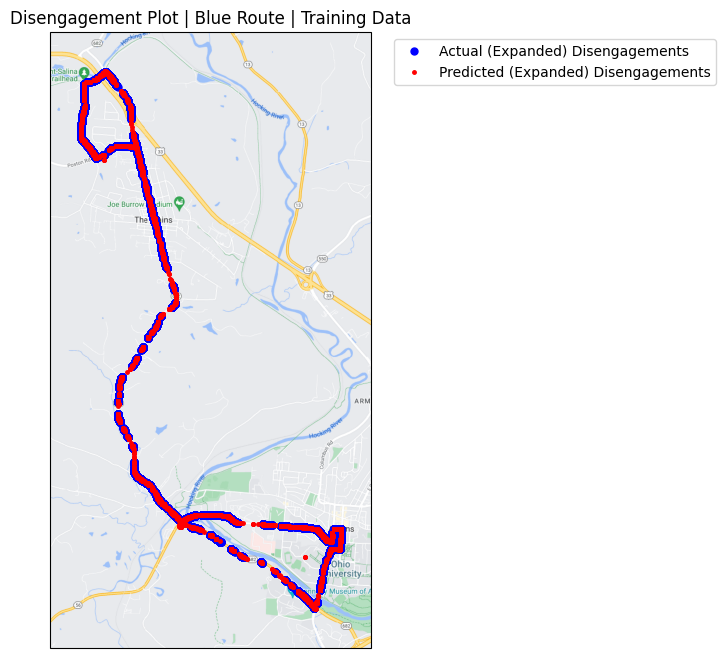

In [40]:
plt.figure( figsize = ( 8, 8 ) )

#

blue_preprocessed_df = pd.concat( blue_preprocessed_dfs )

#

minLat = np.min( np.array( blue_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( blue_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( blue_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( blue_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del blue_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

blue_training_df = pd.concat( blue_training_dfs )

blue_training_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  blue_training_df[ blue_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  blue_training_df[ blue_training_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  blue_training_df[ blue_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  blue_training_df[ blue_training_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del blue_training_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Blue Route | Training Data' )

plt.legend( bbox_to_anchor = ( 1.05, 1.0 ), loc = 'upper left' )

plt.show()

In [42]:
print( f'minLat: { minLat }' )

print( f'maxLat: { maxLat }' )

print( f'minLon: { minLon }' )

print( f'maxLon: { maxLon }' )

minLat: 39.31899122387631
maxLat: 39.38797086107572
minLon: -82.14449476722909
maxLon: -82.10122278485707


In [183]:
cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = blue_training_dfs, \
                                                                               test_dfs = blue_testing_dfs, \
                                                                               X_colnames = X_colnames, \
                                                                               y_colname = y_colname, \
                                                                               dt_random_state = 0, \
                                                                               y_labels = [ 0, 1 ], \
                                                                               **parameters )

tn, fp, fn, tp = cm_values.values()

In [184]:
_ = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = True )

True_Positives: 488, False_Positives: 9310
False_Negatives: 7128, True_Negatives: 1119345

Positive_Precision: 0.050

Positive_Recall: 0.064

F1_Score: 0.056

Accuracy: 0.986
Balanced_Accuracy: 0.529


In [185]:
blue_testing_df = pd.concat( blue_testing_dfs )

#

unique_disengagement_recall_ = cfs.unique_disengagement_recall( y_true = y_test, \
                                                                y_pred = y_pred_test, \
                                                                true_DisengagementExpandedID_col = blue_testing_df[ 'DisengagementExpandedID' ] )

#

del blue_testing_df

for key, val in unique_disengagement_recall_.items():

    if ( key == 'unique_disengagement_recall' ):

        print( f'{ key }: { val:.3f}' )

    else:

        print( f'{ key }: { val }' )

unique_disengagement_recall: 0.160
num_of_unique_tp_DisengagementIDs: 34
num_of_unique_DisengagementIDs: 213


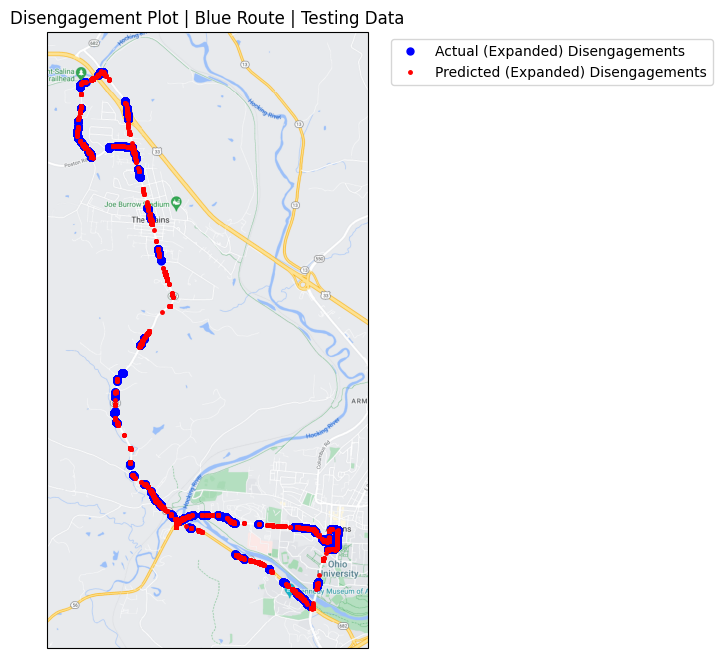

In [186]:
plt.figure( figsize = ( 8, 8 ) )

#

blue_preprocessed_df = pd.concat( blue_preprocessed_dfs )

#

minLat = np.min( np.array( blue_preprocessed_df[ 'latitude' ] ) )

maxLat = np.max( np.array( blue_preprocessed_df[ 'latitude' ] ) )

minLon = np.min( np.array( blue_preprocessed_df[ 'longitude' ] ) )

maxLon = np.max( np.array( blue_preprocessed_df[ 'longitude' ] ) )

expansion_coeff = 0.005

#

del blue_preprocessed_df

#

street_map = GoogleTiles( style = 'street' )

ax = plt.axes( projection = street_map.crs )

ax.set_extent( [ minLon - expansion_coeff , maxLon + expansion_coeff, minLat - expansion_coeff, maxLat + expansion_coeff ], ccrs.PlateCarree() )

ax.add_image(street_map, 14)

#

blue_testing_df = pd.concat( blue_testing_dfs )

blue_testing_df[ 'pred_BinaryDisengagementExpanded' ] = y_pred_test

#

actual_disengagement_lat_list_test =  blue_testing_df[ blue_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

actual_disengagement_lon_list_test =  blue_testing_df[ blue_testing_df[ 'BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

pred_disengagement_lat_list_test =  blue_testing_df[ blue_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'latitude' ]

pred_disengagement_lon_list_test =  blue_testing_df[ blue_testing_df[ 'pred_BinaryDisengagementExpanded' ] == 1 ][ 'longitude' ]

#

del blue_testing_df

#

plt.plot( actual_disengagement_lon_list_test, 
          actual_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'blue',  
          ms = 5, 
          label = 'Actual (Expanded) Disengagements' )

plt.plot( pred_disengagement_lon_list_test, 
          pred_disengagement_lat_list_test, 
          transform = ccrs.PlateCarree(), 
          marker = 'o', 
          ls = '', 
          color = 'red', 
          ms = 2.5,
          label = 'Predicted (Expanded) Disengagements' )

plt.title( 'Disengagement Plot | Blue Route | Testing Data' )

plt.legend( bbox_to_anchor = ( 1.05, 1.0 ), loc = 'upper left' )

plt.show()

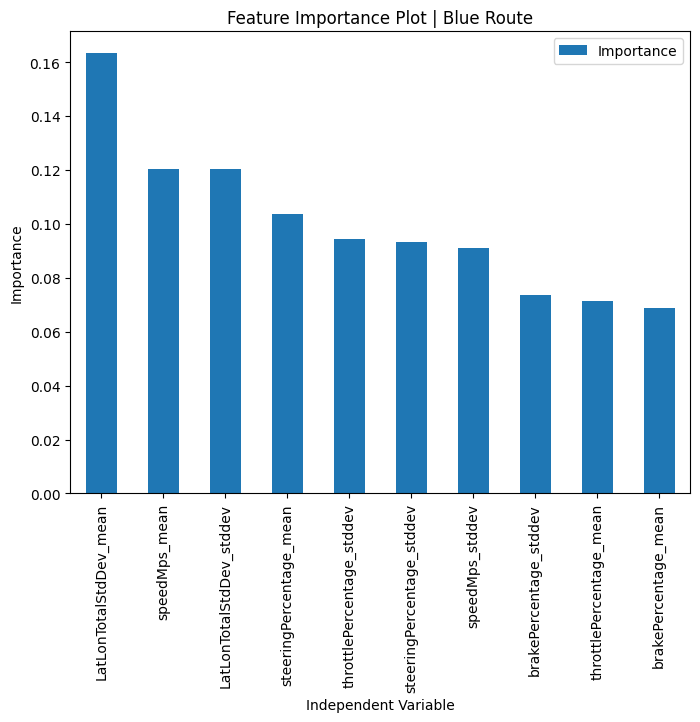

In [187]:
feat_importances = pd.DataFrame( model.feature_importances_, index = X_colnames, columns = [ "Importance" ] )

feat_importances.sort_values( by = 'Importance', ascending = False, inplace = True )

feat_importances.plot( kind = 'bar', figsize = ( 8, 6 ) )

plt.xlabel( 'Independent Variable' )

plt.ylabel( 'Importance' )

plt.title( 'Feature Importance Plot | Blue Route' )

plt.show()